# ReAct Agent

In [ ]:
# uv add langchain-tavily

In [ ]:
from dotenv import load_dotenv

load_dotenv()

## ReAct 패턴이란

ReAct는 **Reasoning + Acting**의 줄임말이다.

기반 기술은 **Function Calling**(Tool Use)이다. LLM이 응답으로 텍스트 대신 "이 함수를 이 인자로 호출해줘"라는 **tool_calls**를 반환하면, 시스템이 해당 함수를 실행하고 결과를 다시 LLM에게 전달한다. ReAct는 이 Function Calling을 **루프 안에서 반복**하는 패턴이다.

```
Think   → LLM이 현재 상황을 분석하고, 어떤 Tool을 호출할지 결정
Act     → tool_calls 응답 → 시스템이 Tool을 실행
Observe → Tool 결과를 LLM에게 전달
(반복)
Answer  → tool_calls가 없으면 최종 답변
```
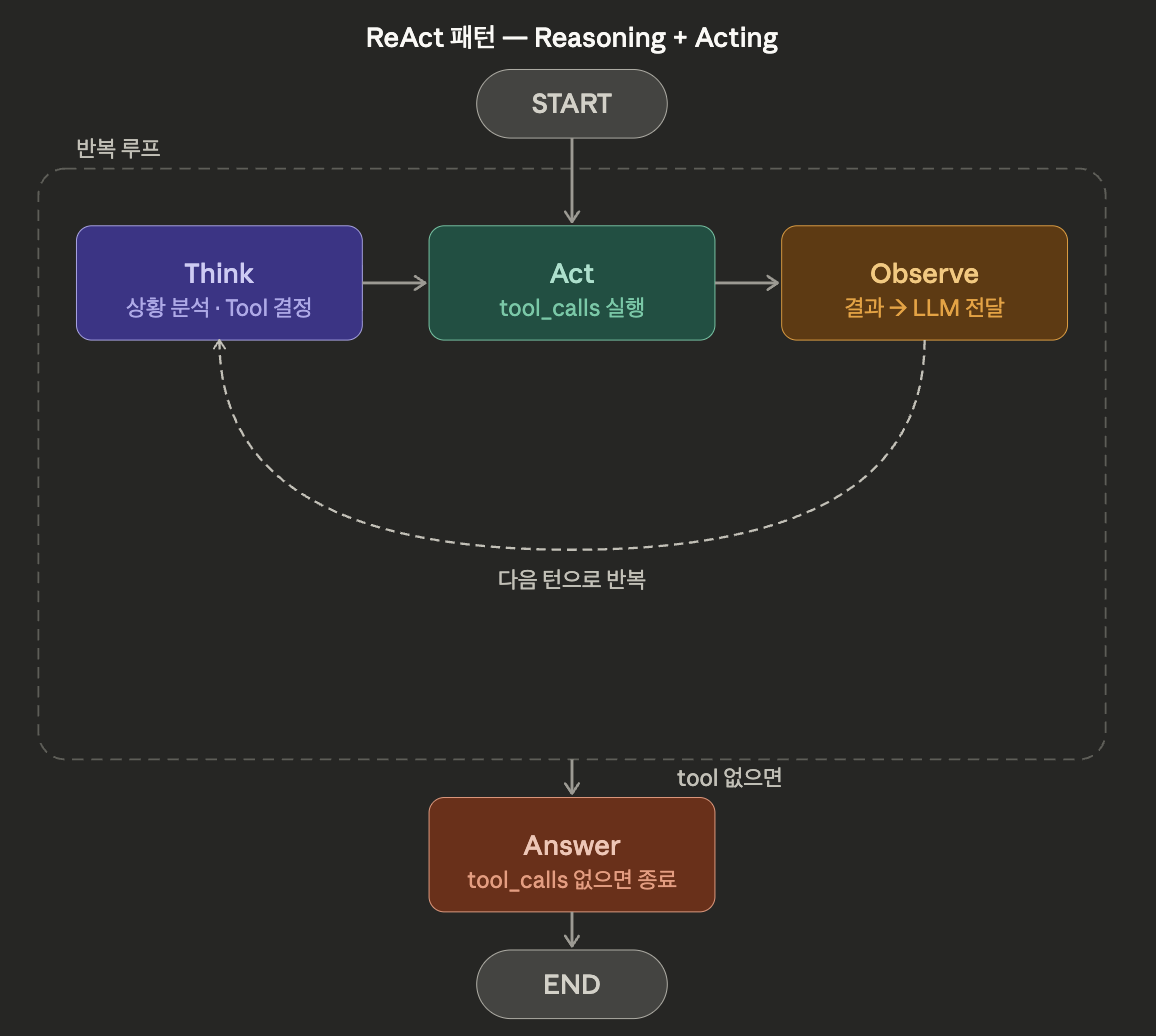
핵심은 **LLM이 스스로 판단**한다는 점이다. 어떤 Tool을 호출할지, 몇 번 반복할지, 언제 멈출지를 LLM이 매 턴마다 결정한다.

LangGraph에서는 `ToolNode`와 `tools_condition`이 이 루프를 **그래프 구조로 표현**한다.

```
START → chatbot → tools_condition → ToolNode → chatbot → ... → END
```

## Tool 정의

ReAct Agent가 사용할 Tool을 정의한다.

In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo

from langchain_tavily import TavilySearch
from langchain_core.tools import tool

# 웹 검색 Tool
search = TavilySearch(max_results=3)


# 현재 시간 Tool
@tool
def get_current_time(timezone: str = "Asia/Seoul") -> str:
    """현재 날짜와 시간을 반환한다."""
    now = datetime.now(ZoneInfo(timezone))
    return now.strftime("%Y-%m-%d %H:%M:%S (%A)")


tools = [search, get_current_time]
print(f"등록된 Tool: {[t.name for t in tools]}")

## ReAct Agent 구현

### State 정의

`MessagesState`는 `messages: Annotated[list, add_messages]`가 이미 정의된 편의 클래스다. 대부분의 챗봇/에이전트에서 이것만으로 충분하다.

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Tool을 LLM에 바인딩
llm_with_tools = llm.bind_tools(tools)

### ToolNode와 tools_condition

이 두 가지가 ReAct 루프의 핵심이다.

#### ToolNode

LLM의 `tool_calls`를 받아서 실제 함수를 실행해주는 노드다. 내부적으로 다음을 자동 처리한다.

1. LLM 응답에서 `tool_calls`를 파싱 (함수 이름 + 인자)
2. 해당 함수를 실행
3. 결과를 `ToolMessage`로 감싸서 State에 추가

직접 구현하면 이렇게 된다:

```python
for tool_call in response.tool_calls:
    tool_fn = tool_map[tool_call["name"]]
    result = tool_fn.invoke(tool_call["args"])
    messages.append(ToolMessage(content=result, tool_call_id=tool_call["id"]))
```

#### tools_condition

LLM 응답에 `tool_calls`가 있으면 `"tools"` 노드로, 없으면 `END`로 보내는 라우팅 함수다.

직접 구현하면 이렇게 된다:

```python
def should_continue(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END
```

| 수동 구현 | LangGraph |
|---|---|
| `if response.tool_calls` 분기 | `tools_condition` 조건부 엣지 |
| Tool 실행 + `ToolMessage` 추가 | `ToolNode`가 자동 처리 |
| `messages` 리스트 직접 관리 | `MessagesState`가 자동 관리 |

### 노드와 그래프 구성

In [ ]:
def chatbot(state: MessagesState):
    """LLM을 호출하는 노드. Tool 호출이 필요하면 tool_calls가 포함된 메시지를 반환한다."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 그래프 구성
graph_builder = StateGraph(MessagesState)

# 노드 등록
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))

# 엣지 연결
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()

print("그래프 컴파일 완료")

`add_conditional_edges`에서 세 번째 인자(dictionary 매핑)가 생략되어 있다. 라우팅 함수의 반환값이 **노드 이름이나 `END`와 일치**하면 매핑을 생략할 수 있다.

```python
# dictionary 매핑 명시 (langgraph-basic 강의에서 다룬 방식)
graph_builder.add_conditional_edges("chatbot", tools_condition, {
    "tools": "tools",
    END: END,
})

# 라우팅 함수의 반환값이 노드 이름 / END와 일치하면 생략 가능
graph_builder.add_conditional_edges("chatbot", tools_condition)
```

`tools_condition`은 내부적으로 `"tools"` 또는 `END`를 반환하는데, 이 값들이 그래프의 노드 이름과 `END`에 그대로 대응하므로 매핑이 필요 없다.

### 그래프 시각화

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 실행 및 스트리밍

같은 질문으로 `invoke`와 `stream`의 차이를 비교한다.

- `invoke`: 그래프 전체 실행이 끝난 뒤 최종 결과를 한 번에 받는다
- `stream`: 각 노드가 실행될 때마다 결과를 하나씩 받는다

### invoke로 실행

In [ ]:
question = "2024년 노벨 물리학상 수상자가 누구야?"

result = graph.invoke({"messages": [("user", question)]})

for msg in result["messages"]:
    print(f"[{msg.type}] {msg.content[:300]}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  -> Tool 호출: {[tc['name'] for tc in msg.tool_calls]}")
    print()

### stream으로 노드별 출력 확인

같은 질문을 `stream`으로 실행한다. 각 노드가 실행될 때마다 `{노드이름: 출력}` 형태의 event를 받는다.

In [ ]:
for event in graph.stream({"messages": [("user", question)]}):
    for node_name, value in event.items():
        last_msg = value["messages"][-1]
        print(f"[{node_name}] {last_msg.type}: {last_msg.content[:200]}")
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            print(f"  Tool 호출: {last_msg.tool_calls}")
        print()

## 비결정성(Non-determinism)

ReAct Agent는 **매 실행마다 결과가 달라질 수 있다.** LLM이 매 턴마다 "어떤 Tool을 호출할지, 어떤 인자를 넘길지"를 스스로 판단하기 때문이다.

예를 들어 "지금 뉴욕은 어때?"라는 질문에 대해:
- 실행 1: `get_current_time("America/New_York")` → 시간만 확인
- 실행 2: `tavily_search("뉴욕 날씨")` → 날씨 검색
- 실행 3: 두 Tool 모두 호출

이처럼 **어떤 Tool을 선택할지** 자체가 달라질 수 있고, 이는 **정상적인 동작**이다. `temperature=0`이면 거의 동일한 결과가 나오므로, `temperature=1`로 올려서 비결정성을 직접 확인해보자.

In [ ]:
# temperature=1로 설정한 그래프로 같은 질문을 3번 실행
llm_high_temp = ChatOpenAI(model="gpt-4o-mini", temperature=1).bind_tools(tools)


def chatbot_high_temp(state: MessagesState):
    return {"messages": [llm_high_temp.invoke(state["messages"])]}


builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot_high_temp)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
graph_high_temp = builder.compile()

question = "지금 뉴욕은 어때?"

for i in range(3):
    result = graph_high_temp.invoke({"messages": [("user", question)]})
    for msg in result["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            calls = [(tc["name"], tc["args"]) for tc in msg.tool_calls]
            print(f"실행 {i+1}: {calls}")

같은 질문이어도 Tool 호출 순서나 횟수가 달라질 수 있다. `temperature=0`으로 설정하면 결정성이 높아지지만 완전히 보장되지는 않는다.

## Fallback 전략

Agent가 Tool 호출을 무한 반복하면 비용과 시간이 낭비된다. `recursion_limit`으로 최대 반복 횟수를 제한하고, 실패 시 부분 결과를 반환하는 패턴을 구현한다.

`recursion_limit`은 **노드 실행 횟수**를 제한한다. 예를 들어 `recursion_limit=3`이면 노드를 3번까지만 거칠 수 있다.

```
chatbot(1) → tools(2) → chatbot(3) → 여기서 제한 초과
```

Tool을 한 번이라도 사용하면 최소 chatbot → tools → chatbot = 3스텝이 필요하므로, 너무 낮게 설정하면 정상적인 요청도 실패할 수 있다.

In [ ]:
from langgraph.errors import GraphRecursionError


def invoke_with_fallback(graph, inputs, config=None, max_steps=10):
    """recursion_limit을 설정하고, 초과 시 부분 결과를 반환한다."""
    if config is None:
        config = {}

    config["recursion_limit"] = max_steps

    try:
        result = graph.invoke(inputs, config=config)
        return result
    except GraphRecursionError:
        print(f"[Fallback] 최대 반복 횟수({max_steps})에 도달했습니다.")
        print("부분 결과를 반환합니다.")
        return {
            "messages": [
                ("ai", "요청을 완전히 처리하지 못했습니다. 질문을 더 구체적으로 바꿔주시거나, 다시 시도해주세요.")
            ]
        }

In [ ]:
# 정상 실행 (넉넉한 recursion_limit)
result = invoke_with_fallback(
    graph,
    {"messages": [("user", "오늘 주요 뉴스를 검색해서 요약해줘")]},
    max_steps=15,
)
last = result["messages"][-1]
print(last.content if hasattr(last, "content") else last[1])

In [ ]:
# 같은 질문을 극단적으로 낮은 recursion_limit으로 실행하여 fallback 테스트
result = invoke_with_fallback(
    graph,
    {"messages": [("user", "오늘 주요 뉴스를 검색해서 요약해줘")]},
    max_steps=3,
)
last = result["messages"][-1]
print(last.content if hasattr(last, "content") else last[1])

실무에서 `recursion_limit`의 권장 값:

| 상황 | 권장 값 |
|------|--------|
| 단순 Q&A (Tool 1~2회) | 10~15 |
| 복잡한 리서치 | 20~30 |
| 기본값 | 25 |

### Tool 장애 시 대체 경로

특정 Tool이 실패했을 때 대체 Tool로 전환하는 패턴이다.

In [ ]:
@tool
def primary_search(query: str) -> str:
    """웹에서 정보를 검색합니다."""
    # 실패 시뮬레이션
    raise Exception("API 서버 장애")

@tool
def fallback_search(query: str) -> str:
    """백업 검색 엔진으로 정보를 검색합니다."""
    return f"[백업 검색 결과] {query}에 대한 정보입니다."

# Tool에 fallback을 연결
search_with_fallback = primary_search.with_fallbacks([fallback_search])

# 단독 테스트
result = search_with_fallback.invoke("LangGraph란?")
print(result)

`with_fallbacks()`로 Tool 체인을 만들면, 첫 번째 Tool이 실패했을 때 자동으로 다음 Tool을 시도한다. `ToolNode`에 fallback이 연결된 Tool을 넣으면 Agent 그래프 안에서도 동일하게 동작한다. 실무에서 외부 API 의존성이 높은 Tool에 필수적인 패턴이다.

## 실습 문제

Tool 강의에서 만든 TMDB Tool(`search_movies`, `get_movie_detail`)을 LangGraph ReAct Agent로 구성하라.

**요구사항**:
1. `search_movies`와 `get_movie_detail` Tool을 정의한다
2. `ToolNode` + `tools_condition`으로 ReAct Agent 그래프를 구성한다
3. 아래 질문들이 정상 동작하는지 확인한다

```
"인셉션 감독이 누구야?"        → search_movies → get_movie_detail 순차 호출
"기생충 러닝타임 알려줘"       → search_movies → get_movie_detail 순차 호출
"안녕하세요!"                 → Tool 호출 없이 바로 응답
```